# InstaNexus demo — assembling a nanobody from de novo PSMs

This notebook walks through the **InstaNexus** workflow on a real nanobody
dataset (`nb1_reduced_demo`): starting from raw PSM predictions produced by a
de novo sequencing tool (InstaNovo), it preprocesses the data, assembles
overlapping peptides into scaffolds with a De Bruijn graph assembler, clusters
and aligns the scaffolds, and derives consensus sequences.

All input files are bundled inside the `demo/` folder so the notebook runs
identically in a GitHub Codespace, on Binder, or locally.

By the end you will have:
1. Verified all required tools are available.
2. Run the `instanexus` CLI end-to-end on the demo CSV.
3. Inspected assembled scaffolds, consensus sequences, peptide coverage, and
   sequence logos.

## 1. Environment check

InstaNexus depends on two external binaries in addition to the Python package:

- **MMseqs2** (`mmseqs`) — fast clustering of assembled scaffolds
- **Clustal Omega** (`clustalo`) — multiple sequence alignment

If you are running inside the provided devcontainer or Binder image both are
already installed. A ⚠️ warning below means the binary is missing but the
notebook will still run up to (and including) section 4, which will error at
the clustering step.

In [11]:
import shutil
import subprocess
import sys

def check_tool(name: str, cmd: list, version_in_stderr: bool = False) -> None:
    path = shutil.which(cmd[0])
    if path is None:
        print(f"⚠️  {name:12s}: NOT FOUND on PATH")
        return
    result = subprocess.run(cmd, capture_output=True, text=True)
    raw = (result.stderr if version_in_stderr else result.stdout).strip()
    first_line = raw.splitlines()[0] if raw else "(no output)"
    print(f"✅ {name:12s}: {first_line}  [{path}]")

check_tool("python",    [sys.executable, "--version"])
check_tool("mmseqs",    ["mmseqs", "version"])
check_tool("clustalo",  ["clustalo", "--version"], version_in_stderr=True)
check_tool("instanexus", [sys.executable, "-m", "instanexus.main", "--help"])


✅ python      : Python 3.11.14  [/Users/marcor/Desktop/marco_replaced_mac/InstaNexus/.venv/bin/python]
⚠️  mmseqs      : NOT FOUND on PATH
⚠️  clustalo    : NOT FOUND on PATH
✅ instanexus  : usage: main.py [-h] --input-csv INPUT_CSV [--folder-outputs FOLDER_OUTPUTS]  [/Users/marcor/Desktop/marco_replaced_mac/InstaNexus/.venv/bin/python]


## 2. Parameters

All paths and pipeline parameters are defined here. `DEMO_DIR` is resolved as
the directory containing this notebook, so all paths work without edits in any
environment (Codespace, Binder, local).

In [12]:
from pathlib import Path

# Resolve the demo/ folder reliably inside a Jupyter kernel
# (IPython sets __vsc_ipynb_file__ in VS Code; Binder/JupyterLab use __session__)
import IPython
_ip = IPython.get_ipython()
_nb_path = None
if _ip is not None:
    for _attr in ("__vsc_ipynb_file__", "__session__"):
        _val = _ip.user_ns.get(_attr)
        if _val:
            _nb_path = Path(_val)
            break

if _nb_path is not None:
    DEMO_DIR = _nb_path.parent.resolve()
else:
    # Fallback: CWD (works when notebook CWD == demo/)
    DEMO_DIR = Path().resolve()

print(f"DEMO_DIR = {DEMO_DIR}")

# ── Paths (all files bundled in demo/) ───────────────────────────────────
INPUT_CSV     = DEMO_DIR / "nb1_reduced_demo.csv"   # raw PSM predictions
METADATA_JSON = DEMO_DIR / "sample_metadata.json"   # protein sequence, chain, proteases
CONTAM_FASTA  = DEMO_DIR / "contaminants.fasta"     # contaminant sequences to filter
OUTPUT_DIR    = DEMO_DIR / "output_demo_nb1"         # pipeline writes everything here

# ── Pipeline parameters ───────────────────────────────────────────────────
assembly_mode  = "dbg"   # De Bruijn graph assembler (alternatives: "greedy", "dbg_weighted")
conf           = 0.9     # minimum calibrated confidence; PSMs below this are discarded
kmer_size      = 7       # k-mer length for the De Bruijn graph (only for dbg* modes)
min_overlap    = 3       # minimum residue overlap required to merge two reads/contigs
size_threshold = 12      # minimum contig length kept after assembly
min_seq_id     = 0.85    # minimum sequence identity for MMseqs2 clustering
coverage       = 0.8     # minimum alignment coverage for MMseqs2 clustering

for label, val in [
    ("INPUT_CSV",     INPUT_CSV),
    ("METADATA_JSON", METADATA_JSON),
    ("CONTAM_FASTA",  CONTAM_FASTA),
]:
    status = "✅" if Path(val).exists() else "⚠️  MISSING"
    print(f"{status}  {label} = {val}")
print(f"         OUTPUT_DIR = {OUTPUT_DIR}")


DEMO_DIR = /Users/marcor/Desktop/marco_replaced_mac/InstaNexus/demo
✅  INPUT_CSV = /Users/marcor/Desktop/marco_replaced_mac/InstaNexus/demo/nb1_reduced_demo.csv
✅  METADATA_JSON = /Users/marcor/Desktop/marco_replaced_mac/InstaNexus/demo/sample_metadata.json
✅  CONTAM_FASTA = /Users/marcor/Desktop/marco_replaced_mac/InstaNexus/demo/contaminants.fasta
         OUTPUT_DIR = /Users/marcor/Desktop/marco_replaced_mac/InstaNexus/demo/output_demo_nb1


## 3. Inspecting the input

`nb1_reduced_demo.csv` contains raw PSM predictions — one row per spectrum —
with the predicted peptide sequence (`prediction_untokenised`) and a calibrated
confidence score (`calibrated_confidence`).

In [13]:
import pandas as pd

df_raw = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df_raw):,} PSMs  |  {df_raw.shape[1]} columns")
df_raw[["spectrum_id", "prediction_untokenised", "calibrated_confidence"]].head()


Loaded 49,322 PSMs  |  18 columns


,spectrum_id,prediction_untokenised,calibrated_confidence
0,20250124_FJ_VOLTA_MWN_Easy15_35min_1835_DDA_Na...,ASASAFAHPPVSIIQEKNDIQIQVQAEQDNIADAEER,8.241426e-08
1,20250124_FJ_VOLTA_MWN_Easy15_35min_1835_DDA_Na...,TTSPTTSPPVPSPGSPHSPGHGIQWS[UNIMOD:21]EEETEDEEEEK,3.075032e-03
2,20250124_FJ_VOLTA_MWN_Easy15_35min_1835_DDA_Na...,AGPPSPGPGPNGTASAESASPTEDEEGKKYVGDSYDSSAK,1.712382e-38
3,20250124_FJ_VOLTA_MWN_Easy15_35min_1835_DDA_Na...,SSSGSSQSHSNGSITDSPVSIFHEDDPDSKDIIITIIR,1.342932e-08
4,20250124_FJ_VOLTA_MWN_Easy15_35min_1835_DDA_Na...,[UNIMOD:385]PDIHDSGDAPQPDVKEEEEEEKEEEKDKGDEEEEGEK,2.445717e-03


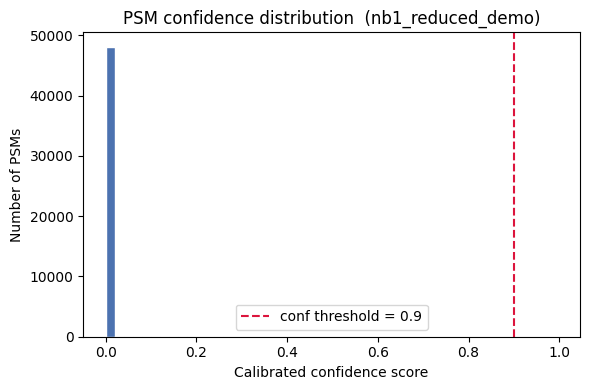

53 / 49,322 PSMs pass conf ≥ 0.9  (0.1%)


In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df_raw["calibrated_confidence"].dropna(), bins=50, color="#4C72B0", edgecolor="white")
ax.axvline(conf, color="crimson", linestyle="--", linewidth=1.5,
           label=f"conf threshold = {conf}")
ax.set_xlabel("Calibrated confidence score")
ax.set_ylabel("Number of PSMs")
ax.set_title(f"PSM confidence distribution  ({INPUT_CSV.stem})")
ax.legend()
fig.tight_layout()
plt.show()

n_kept = int((df_raw["calibrated_confidence"] >= conf).sum())
print(f"{n_kept:,} / {len(df_raw):,} PSMs pass conf ≥ {conf}  ({100*n_kept/len(df_raw):.1f}%)")


## 4. Running the InstaNexus pipeline

The `instanexus` CLI is called via `subprocess` using the same Python
interpreter that runs this notebook (`sys.executable -m instanexus.main`), so
it resolves the correct venv in any environment.

The five pipeline steps are:
1. **Preprocessing** — filter by confidence, remove contaminants, split by protease
2. **Assembly** — build a De Bruijn graph and extract scaffolds
3. **Clustering** — group similar scaffolds with MMseqs2
4. **Alignment** — align each cluster with Clustal Omega
5. **Consensus** — derive consensus sequences and plots

> **⏱ Runtime:** ~1–3 minutes on a typical laptop for this dataset (~50 k PSMs).

In [15]:
import subprocess, sys

cmd = [
    sys.executable, "-m", "instanexus.main",
    "--input-csv",               str(INPUT_CSV),
    "--metadata-json-path",      str(METADATA_JSON),
    "--contaminants-fasta-path", str(CONTAM_FASTA),
    "--output-dir",              str(OUTPUT_DIR),
    "--assembly-mode",           assembly_mode,
    "--conf",                    str(conf),
    "--kmer-size",               str(kmer_size),
    "--min-overlap",             str(min_overlap),
    "--size-threshold",          str(size_threshold),
    "--min-seq-id",              str(min_seq_id),
    "--coverage",                str(coverage),
]

print("Running:\n  " + " \\\n  ".join(cmd[2:]))  # print just the CLI args
print()

result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout[-3000:] if result.stdout else "(no stdout)")
if result.returncode != 0:
    print("\n--- STDERR ---")
    print(result.stderr[-2000:])
print(f"\nExit code: {result.returncode}")


Running:
  instanexus.main \
  --input-csv \
  /Users/marcor/Desktop/marco_replaced_mac/InstaNexus/demo/nb1_reduced_demo.csv \
  --metadata-json-path \
  /Users/marcor/Desktop/marco_replaced_mac/InstaNexus/demo/sample_metadata.json \
  --contaminants-fasta-path \
  /Users/marcor/Desktop/marco_replaced_mac/InstaNexus/demo/contaminants.fasta \
  --output-dir \
  /Users/marcor/Desktop/marco_replaced_mac/InstaNexus/demo/output_demo_nb1 \
  --assembly-mode \
  dbg \
  --conf \
  0.9 \
  --kmer-size \
  7 \
  --min-overlap \
  3 \
  --size-threshold \
  12 \
  --min-seq-id \
  0.85 \
  --coverage \
  0.8

Starting assembly pipeline with dbg...


Exit code: 0


## 5. Inspecting the outputs

The pipeline writes a deterministic directory structure:

```
output_demo_nb1/
├── cleaned.csv
├── summary.tsv
└── scaffolds/
    ├── scaffolds.fasta
    ├── clustering/
    ├── alignment/           ← Clustal Omega .afa files
    └── consensus/
        ├── consensus_fasta/ ← one FASTA per scaffold cluster
        ├── consensus_stats.json
        ├── heatmap/         ← SVG coverage heatmaps
        └── logo/            ← SVG sequence logos
```

In [16]:
from Bio import SeqIO

scaffolds_dir       = OUTPUT_DIR / "scaffolds"
consensus_dir       = scaffolds_dir / "consensus"
consensus_fasta_dir = consensus_dir / "consensus_fasta"

if not OUTPUT_DIR.exists():
    print("⚠️  OUTPUT_DIR not found — run section 4 first.")
else:
    print(f"Files generated in output_demo_nb1/:")
    for p in sorted(OUTPUT_DIR.rglob("*")):
        if p.is_file():
            print(f"  {p.relative_to(OUTPUT_DIR)}")


Files generated in output_demo_nb1/:
  cleaned.csv
  scaffolds/alignment/scaffold_0001_aligned.afa
  scaffolds/alignment/scaffold_0002_aligned.afa
  scaffolds/alignment/scaffold_0003_aligned.afa
  scaffolds/alignment/scaffold_0004_aligned.afa
  scaffolds/alignment/scaffold_0005_aligned.afa
  scaffolds/clustering/cluster_fasta/scaffold_0001.fasta
  scaffolds/clustering/cluster_fasta/scaffold_0002.fasta
  scaffolds/clustering/cluster_fasta/scaffold_0003.fasta
  scaffolds/clustering/cluster_fasta/scaffold_0004.fasta
  scaffolds/clustering/cluster_fasta/scaffold_0005.fasta
  scaffolds/clustering/scaffolds_all_seqs.fasta
  scaffolds/clustering/scaffolds_cluster.tsv
  scaffolds/clustering/scaffolds_rep_seq.fasta
  scaffolds/consensus/consensus_fasta/scaffold_0001_aligned_consensus.fasta
  scaffolds/consensus/consensus_fasta/scaffold_0002_aligned_consensus.fasta
  scaffolds/consensus/consensus_fasta/scaffold_0003_aligned_consensus.fasta
  scaffolds/consensus/consensus_fasta/scaffold_0004_alig

In [17]:
consensus_records = []
if consensus_fasta_dir.exists():
    for fasta_path in sorted(consensus_fasta_dir.glob("*_consensus.fasta")):
        consensus_records.extend(SeqIO.parse(fasta_path, "fasta"))
    print(f"Found {len(consensus_records)} consensus sequence(s)\n")
    for record in consensus_records:
        print(f">{record.id}  (length={len(record.seq)})")
        print(record.seq)
        print()
else:
    print("⚠️  consensus_fasta/ not found — run section 4 first.")


Found 5 consensus sequence(s)

>scaffold_0001_consensus  (length=21)
VAVLTSAGNTNYAESVKGRFT

>scaffold_0002_consensus  (length=19)
VFLQMNSLKPDDTAVYY-H

>scaffold_0003_consensus  (length=16)
LSGTVDSQAQSDRAES

>scaffold_0004_consensus  (length=14)
MRWYRQAPGKQREL

>scaffold_0005_consensus  (length=13)
VAVLTSAGNTNYY



## 6. Coverage plot

The `heatmap/` folder contains per-scaffold SVG heatmaps showing how many
aligned peptides cover each position in the consensus sequence.

Showing: scaffold_0001_aligned_heatmap.svg


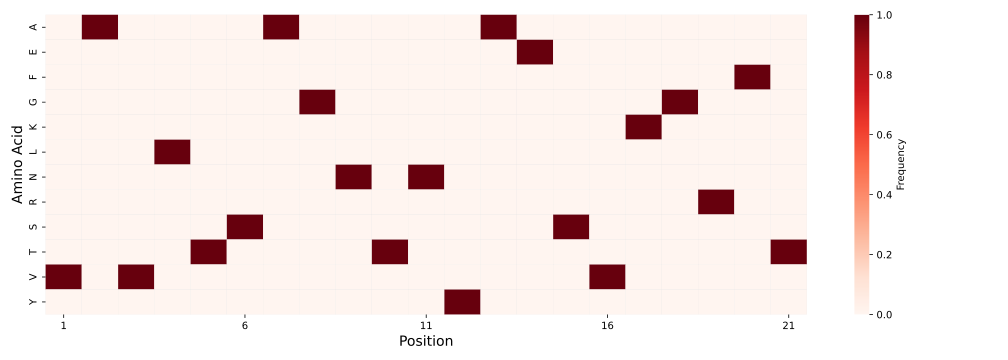

In [18]:
from IPython.display import SVG, display

heatmap_dir   = consensus_dir / "heatmap"
heatmap_files = sorted(heatmap_dir.glob("*_heatmap.svg")) if heatmap_dir.exists() else []

if heatmap_files:
    print(f"Showing: {heatmap_files[0].name}")
    display(SVG(filename=str(heatmap_files[0])))
else:
    print("⚠️  No heatmap files found. Run section 4 first.")


## 7. Sequence logo

`logomaker` draws a sequence logo from the multiple alignment supporting each
scaffold. Letter height is proportional to amino-acid count at that position.

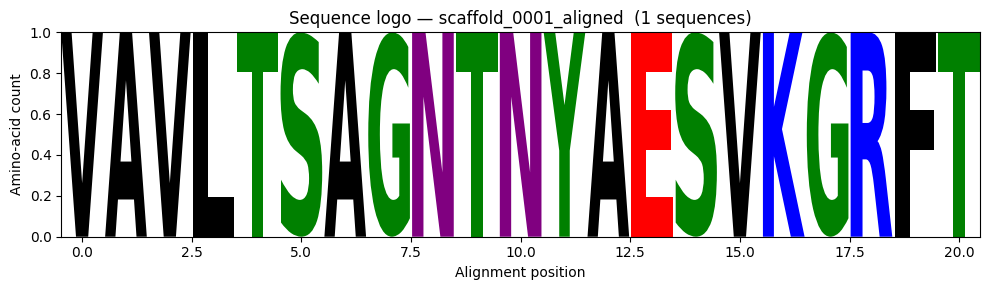

In [19]:
import logomaker
from Bio import AlignIO

alignment_dir = scaffolds_dir / "alignment"
afa_files     = sorted(alignment_dir.glob("*_aligned.afa")) if alignment_dir.exists() else []

if afa_files:
    afa       = afa_files[0]
    alignment = AlignIO.read(afa, "fasta")
    sequences = [str(rec.seq) for rec in alignment]
    counts_df = logomaker.alignment_to_matrix(sequences=sequences)

    fig, ax = plt.subplots(figsize=(max(8, len(counts_df) // 2), 3))
    logomaker.Logo(counts_df, ax=ax, color_scheme="chemistry")
    ax.set_title(f"Sequence logo — {afa.stem}  ({len(sequences)} sequences)")
    ax.set_xlabel("Alignment position")
    ax.set_ylabel("Amino-acid count")
    fig.tight_layout()
    plt.show()
else:
    print("⚠️  No .afa files found. Run section 4 first.")


## 8. Summary

Textual recap of the run parameters and results.

In [20]:
import json

summary_path = OUTPUT_DIR / "summary.tsv"
stats_path   = consensus_dir / "consensus_stats.json"

print("=" * 60)
print(f"Run:            {INPUT_CSV.stem}")
print(f"Assembly mode:  {assembly_mode}")
print(f"conf:           {conf}  |  kmer_size: {kmer_size}  |  min_overlap: {min_overlap}")
print(f"size_threshold: {size_threshold}  |  min_seq_id: {min_seq_id}  |  coverage: {coverage}")
print(f"Output dir:     {OUTPUT_DIR}")
print("=" * 60)

if summary_path.exists():
    summary_df = pd.read_csv(summary_path, sep="\t")
    print("\n--- summary.tsv ---")
    print(summary_df.T.to_string())

if stats_path.exists():
    with open(stats_path) as f:
        stats = json.load(f)
    print("\n--- consensus_stats.json ---")
    print(json.dumps(stats, indent=2))

n_kept = int((df_raw["calibrated_confidence"] >= conf).sum())
print(f"\n{n_kept:,} / {len(df_raw):,} PSMs passed the confidence filter.")
print(f"{len(consensus_records)} consensus sequence(s) assembled.")
print("\nTip: adjust assembly_mode, kmer_size, or conf in section 2 and re-run section 4.")


Run:            nb1_reduced_demo
Assembly mode:  dbg
conf:           0.9  |  kmer_size: 7  |  min_overlap: 3
size_threshold: 12  |  min_seq_id: 0.85  |  coverage: 0.8
Output dir:     /Users/marcor/Desktop/marco_replaced_mac/InstaNexus/demo/output_demo_nb1

--- summary.tsv ---
                                                                   0
run_name                                            nb1_reduced_demo
assembly_mode                                                    dbg
output_dir                                      demo/output_demo_nb1
scaffolds_fasta       demo/output_demo_nb1/scaffolds/scaffolds.fasta
consensus_dir               demo/output_demo_nb1/scaffolds/consensus
n_consensus_files                                                  5
longest_gap                                                        1
shortest_gap                                                       1
percent_without_gaps                                            80.0
max_consensus_length             